# Notebook 3 — Success rate by relationship (friend vs. stranger)

**Hypothesis:** success rate is higher for friend dyads than stranger dyads.

Uses `success.csv` (Notebook 2) merged with `participants.csv`
(`fetch_metadata_demographics.py`). `relationship_to_interlocutor` is reported per-participant
but describes the dyad, so both partners should report the same category



## 0. Load and merge

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def find_dir_with(filename, start=None, max_up=6):
    d = os.path.abspath(start or os.getcwd())
    for _ in range(max_up):
        cand = os.path.join(d, filename)
        if os.path.isfile(cand):
            return os.path.dirname(cand)
        for sub in ("textgrid_transcripts", "metadata"):
            cand2 = os.path.join(d, sub, filename)
            if os.path.isfile(cand2):
                return os.path.dirname(cand2)
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    raise FileNotFoundError(f"Could not find {filename} nearby.")

success_dir = find_dir_with("success.csv")
meta_dir = find_dir_with("participants.csv")
print("success.csv in:", success_dir)
print("participants.csv in:", meta_dir)

success_df = pd.read_csv(os.path.join(success_dir, "success.csv"))
participants_df = pd.read_csv(os.path.join(meta_dir, "participants.csv"))
print(f"\n{len(success_df)} trials, {len(participants_df)} participants")


success.csv in: /Volumes/TimMurphy/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/scripts/nlp_taboo/Transcript Analysis/textgrid_transcripts
participants.csv in: /Volumes/TimMurphy/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/scripts/nlp_taboo/Transcript Analysis/metadata

400 trials, 20 participants


## 1. Attach relationship to each trial (pair-level)

Check both partners agree on the relationship category before collapsing to one value per
pair -- if they disagree, that pair is worth a manual check rather than silently picking one
answer.


In [3]:
rel_per_pair = participants_df.groupby("pair_id")["relationship_to_interlocutor"]
n_unique = rel_per_pair.nunique()
mismatched_pairs = n_unique[n_unique > 1].index.tolist()

if mismatched_pairs:
    print(f"WARNING: {len(mismatched_pairs)} pair(s) have partners disagreeing on relationship:")
    print(participants_df[participants_df.pair_id.isin(mismatched_pairs)]
          [["pair_id", "participant_id", "relationship_to_interlocutor"]].to_string(index=False))
else:
    print("All pairs agree on relationship_to_interlocutor. Good.")

pair_relationship = rel_per_pair.agg(lambda x: x.mode().iloc[0]).rename("relationship")

other_count = (pair_relationship == "other/unknown").sum()
if other_count:
    print(f"\n{other_count} pair(s) have an unrecognised relationship_to_interlocutor value "
          f"-- check RELATIONSHIP_MAP in fetch_metadata_demographics.py covers all response options.")

results = success_df.merge(pair_relationship, on="pair_id", how="left")
print(f"\n{results.relationship.isna().sum()} trial(s) have no relationship match (pair not in participants.csv)")
print(results.relationship.value_counts())


All pairs agree on relationship_to_interlocutor. Good.

0 trial(s) have no relationship match (pair not in participants.csv)
relationship
stranger    200
friend      200
Name: count, dtype: int64


## 2. Success rate by relationship

Wilson score confidence intervals (more reliable than the normal approximation at these
sample sizes / proportions near 0 or 1).


In [4]:
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return (max(0, center - half), min(1, center + half))

summary = results.groupby("relationship").agg(n=("success", "size"), successes=("success", "sum"))
summary["rate"] = summary.successes / summary.n
summary["ci_low"], summary["ci_high"] = zip(*summary.apply(
    lambda r: wilson_ci(r.successes, r.n), axis=1))
print(summary.round(3).to_string())


                n  successes   rate  ci_low  ci_high
relationship                                        
friend        200        183  0.915   0.868    0.946
stranger      200        182  0.910   0.862    0.942


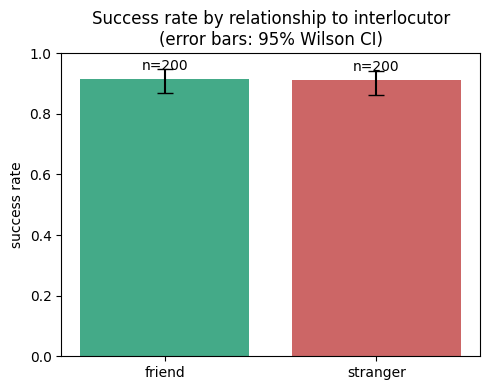

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_df = summary.loc[["friend", "stranger"]] if set(["friend","stranger"]).issubset(summary.index) else summary
yerr = [plot_df.rate - plot_df.ci_low, plot_df.ci_high - plot_df.rate]
ax.bar(plot_df.index, plot_df.rate, yerr=yerr, capsize=6, color=["#4a8", "#c66"])
ax.set_ylabel("success rate"); ax.set_ylim(0, 1)
ax.set_title("Success rate by relationship to interlocutor\n(error bars: 95% Wilson CI)")
for i, (idx, row) in enumerate(plot_df.iterrows()):
    ax.text(i, row.rate + 0.03, f"n={int(row.n)}", ha="center")
plt.tight_layout(); plt.show()


## 3. Statistical test

Chi-square test of independence between relationship and success. With trials nested within
pairs (non-independent observations -- the same dyad contributes many trials), this simple
test treats trials as independent, which isn't strictly correct; §4 below adds a
pair-clustered check as a robustness comparison.


In [6]:
ct = pd.crosstab(results.relationship, results.success)
print(ct)

if ct.shape[0] >= 2 and ct.shape[1] >= 2:
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    print(f"\nchi2 = {chi2:.3f}, df = {dof}, p = {p:.4f}")
    if (expected < 5).any():
        print("Note: some expected cell counts are below 5 -- chi-square approximation may be "
              "unreliable here; consider Fisher's exact test instead (scipy.stats.fisher_exact, "
              "2x2 tables only).")
else:
    print("Not enough categories with data for a chi-square test.")


success       False  True 
relationship              
friend           17    183
stranger         18    182

chi2 = 0.000, df = 1, p = 1.0000


## 4. Pair-level check (robustness)

Since many trials come from the same dyad, a simpler and arguably more appropriate view:
collapse to **one success rate per pair**, then compare the distribution of pair-level rates
between friend and stranger pairs. Fewer data points, but each one is independent.


pair_id relationship  pair_success_rate
103_203     stranger              0.950
108_208     stranger              0.975
109_209     stranger              0.825
115_215       friend              0.875
116_216       friend              0.950
118_218       friend              0.875
123_223       friend              0.925
158_258     stranger              0.825
180_280     stranger              0.975
188_288       friend              0.950


/var/folders/c2/gcn21r4d0131yjb2dvjgy9w40000gn/T/ipykernel_7214/4226261294.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels)


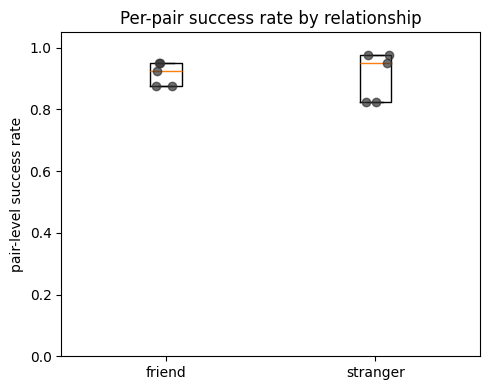


Mann-Whitney U test on pair-level success rates: U = 11.00, p = 0.8310
(non-parametric, appropriate given the very small number of pairs per group)


In [7]:
pair_summary = results.groupby(["pair_id", "relationship"])["success"].mean().reset_index()
pair_summary.columns = ["pair_id", "relationship", "pair_success_rate"]
print(pair_summary.to_string(index=False))

groups = [g["pair_success_rate"].values for _, g in pair_summary.groupby("relationship")]
labels = [name for name, _ in pair_summary.groupby("relationship")]

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(groups, labels=labels)
for i, g in enumerate(groups, start=1):
    ax.scatter(np.random.normal(i, 0.04, size=len(g)), g, alpha=0.7, color="#333", zorder=3)
ax.set_ylabel("pair-level success rate"); ax.set_ylim(0, 1.05)
ax.set_title("Per-pair success rate by relationship")
plt.tight_layout(); plt.show()

if len(groups) == 2 and all(len(g) > 0 for g in groups):
    u_stat, p_mw = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
    print(f"\nMann-Whitney U test on pair-level success rates: U = {u_stat:.2f}, p = {p_mw:.4f}")
    print("(non-parametric, appropriate given the very small number of pairs per group)")


## 5. Controlling for condition and target-word difficulty.

A simple proportion comparison ignores that friend/stranger pairs might happen to have gotten
easier or harder words, or more board vs. ground trials, by chance. Logistic regression lets
relationship's association with success be assessed while holding condition


In [8]:
try:
    import statsmodels.formula.api as smf

    model_df = results.dropna(subset=["relationship", "condition", "success"]).copy()
    model_df["success"] = model_df["success"].astype(int)

    model = smf.logit("success ~ C(relationship) + C(condition)", data=model_df).fit(disp=0)
    print(model.summary())

    print("\nOdds ratios:")
    print(np.exp(model.params))
except ImportError:
    print("statsmodels not installed -- run `pip install statsmodels` to use this cell.\n"
          "The chi-square test and pair-level comparison above don't need it.")


                           Logit Regression Results                           
Dep. Variable:                success   No. Observations:                  400
Model:                          Logit   Df Residuals:                      397
Method:                           MLE   Df Model:                            2
Date:                Wed, 15 Jul 2026   Pseudo R-squ.:                0.003440
Time:                        14:29:19   Log-Likelihood:                -118.28
converged:                       True   LL-Null:                       -118.69
Covariance Type:            nonrobust   LLR p-value:                    0.6648
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       2.2290      0.298      7.490      0.000       1.646       2.812
C(relationship)[T.stranger]    -0.0628      0.354     -0.177      0.859      -0.

## 6. Time to success (effort proxy)

Success rate is near ceiling (~91% both groups) and shows no relationship effect. Time to
success is a continuous measure that isn't capped the same way, and connects more directly to
"communicative effort" -- even if friends and strangers eventually succeed equally often,
friends might get there faster if less clue-negotiation is needed. Restricted to successful
trials only (time_to_success is undefined for failures).

                n  median   mean   q25    q75
relationship                                 
friend        183   11.13  14.32  5.86  18.51
stranger      182    8.46  12.87  5.75  15.44


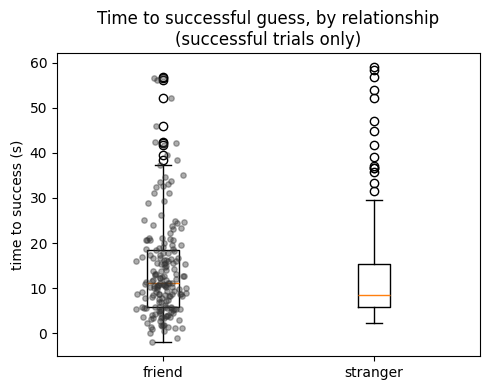

<Figure size 640x480 with 0 Axes>

In [9]:
succ = results[results.success].dropna(subset=["time_to_success"])

print(succ.groupby("relationship")["time_to_success"].agg(
n="size", median="median", mean="mean",
q25=lambda x: x.quantile(.25), q75=lambda x: x.quantile(.75)
).round(2))

groups = [g["time_to_success"].values for _, g in succ.groupby("relationship")]
labels = [name for name, _ in succ.groupby("relationship")]

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(groups, tick_labels=labels)   # tick_labels= (not labels=) for matplotlib >= 3.9
for i, g in enumerate(groups, start=1):
    ax.scatter(np.random.normal(i, 0.05, size=len(g)), g, alpha=0.4, color="#333", s=15, zorder=3)
    ax.set_ylabel("time to success (s)")
    ax.set_title("Time to successful guess, by relationship\n(successful trials only)")
    plt.tight_layout(); plt.show()

Trial level test (same non-independence caveat as success rate analysis)

In [10]:
if len(groups) == 2:
    u, p = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
    print(f"Trial-level Mann-Whitney U test: U = {u:.1f}, p = {p:.4f}")
else:
    print("Need exactly two relationship groups with data for this test.")

Trial-level Mann-Whitney U test: U = 18576.5, p = 0.0564


Pair-level test (robustness check). 

Collapses each pair to its median time_to_success first, so each data point is one independent dyad rather than one of many correlated trials from the same two people.

pair_id relationship  pair_median_time_to_success
103_203     stranger                      10.2605
108_208     stranger                       8.0360
109_209     stranger                       8.4350
115_215       friend                       8.6680
116_216       friend                      11.3130
118_218       friend                      15.2780
123_223       friend                      11.3490
158_258     stranger                      11.0920
180_280     stranger                       6.9190
188_288       friend                       8.2740


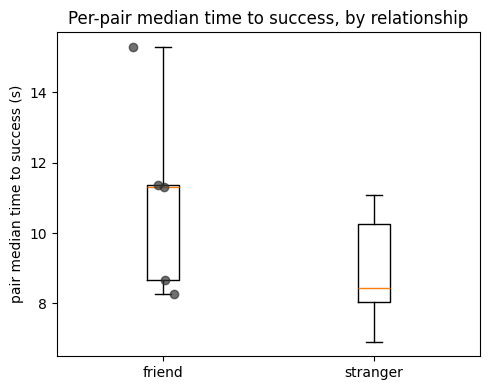

<Figure size 640x480 with 0 Axes>


Pair-level Mann-Whitney U test: U = 20.0, p = 0.1508
(as with success rate, this is the more honest but more underpowered check -- only ~5 pairs per group)


In [11]:
pair_time = succ.groupby(["pair_id", "relationship"])["time_to_success"].median().reset_index()
pair_time.columns = ["pair_id", "relationship", "pair_median_time_to_success"]
print(pair_time.to_string(index=False))

groups2 = [g["pair_median_time_to_success"].values for _, g in pair_time.groupby("relationship")]
labels2 = [name for name, _ in pair_time.groupby("relationship")]

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(groups2, tick_labels=labels2)
for i, g in enumerate(groups2, start=1):
    ax.scatter(np.random.normal(i, 0.05, size=len(g)), g, alpha=0.7, color="#333", zorder=3)
    ax.set_ylabel("pair median time to success (s)")
    ax.set_title("Per-pair median time to success, by relationship")
    plt.tight_layout(); plt.show()

if len(groups2) == 2 and all(len(g) > 0 for g in groups2):
    u2, p2 = stats.mannwhitneyu(groups2[0], groups2[1], alternative="two-sided")
    print(f"\nPair-level Mann-Whitney U test: U = {u2:.1f}, p = {p2:.4f}")
    print("(as with success rate, this is the more honest but more underpowered check --"
    " only ~5 pairs per group)")

Effort proxy: clue giver utterances before the correct guess.

A second, complementary way to look at effort: how many things did the clue giver need to say before the guesser got it? 

In [12]:
transcripts_dir = find_dir_with("transcripts_all.csv")
combined = pd.read_csv(os.path.join(transcripts_dir, "transcripts_all.csv"))

succ_effort = succ.copy()
succ_effort["guess_abs_time"] = succ_effort["clue_giver_start"] + succ_effort["time_to_success"]

effort_rows = []
for _, row in succ_effort.iterrows():
    cg = combined[(combined.trial_id == row.trial_id) & (combined.role == "clue_giver")]
    n_before = (cg.start < row.guess_abs_time).sum()
    effort_rows.append(dict(trial_id=row.trial_id, n_clue_giver_utterances_before_success=n_before))

succ_effort = succ_effort.merge(pd.DataFrame(effort_rows), on="trial_id")

print(succ_effort.groupby("relationship")["n_clue_giver_utterances_before_success"]
.agg(n="size", mean="mean", median="median").round(2))

groups3 = [g["n_clue_giver_utterances_before_success"].values
for _, g in succ_effort.groupby("relationship")]
if len(groups3) == 2:
    u3, p3 = stats.mannwhitneyu(groups3[0], groups3[1], alternative="two-sided")
    print(f"\nMann-Whitney U test (trial-level, same non-independence caveat as above): "
    f"U = {u3:.1f}, p = {p3:.4f}")

                n  mean  median
relationship                   
friend        183  6.24     5.0
stranger      182  5.79     4.0

Mann-Whitney U test (trial-level, same non-independence caveat as above): U = 17956.5, p = 0.1936


# Figures

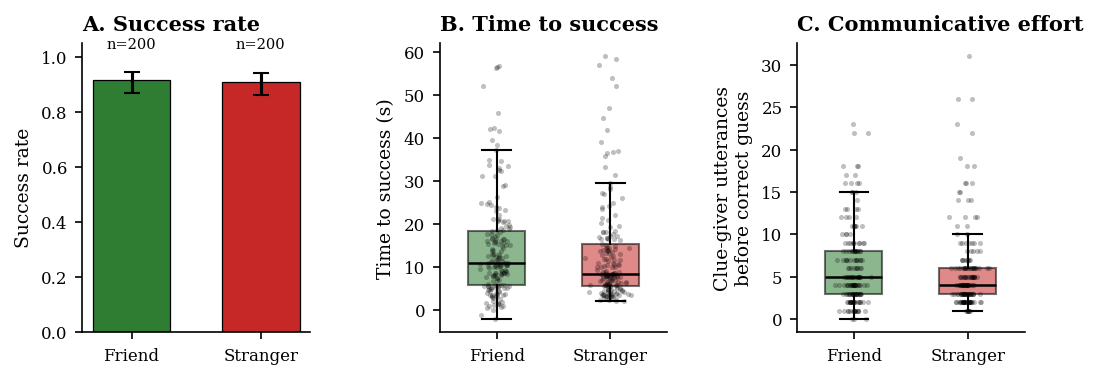

Saved fig_relationship_findings.pdf / .png


In [ ]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

GROUP_ORDER = ["friend", "stranger"]
COLORS = {"friend": "#2E7D32", "stranger": "#C62828"}  # consistent across all panels

fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.6))

# Panel A: success rate with 95% Wilson CI
ax = axes[0]
summary = results.groupby("relationship").agg(n=("success", "size"), successes=("success", "sum"))
summary["rate"] = summary.successes / summary.n
summary["ci_low"], summary["ci_high"] = zip(*summary.apply(lambda r: wilson_ci(r.successes, r.n), axis=1))
summary = summary.loc[GROUP_ORDER]

x = np.arange(len(GROUP_ORDER))
yerr = [summary.rate - summary.ci_low, summary.ci_high - summary.rate]
ax.bar(x, summary.rate, yerr=yerr, capsize=4, width=0.6,
       color=[COLORS[g] for g in GROUP_ORDER], edgecolor="black", linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels([g.capitalize() for g in GROUP_ORDER])
ax.set_ylabel("Success rate")
ax.set_ylim(0, 1.05)
for xi, (idx, row) in zip(x, summary.iterrows()):
    ax.text(xi, 1.02, f"n={int(row.n)}", ha="center", va="bottom", fontsize=7)
ax.set_title("A. Success rate", loc="left", fontweight="bold")

# Panel B: time to success (successful trials only)
ax = axes[1]
data = [succ.loc[succ.relationship == g, "time_to_success"].values for g in GROUP_ORDER]
bp = ax.boxplot(data, tick_labels=[g.capitalize() for g in GROUP_ORDER], patch_artist=True,
                 widths=0.5, showfliers=False, medianprops=dict(color="black", linewidth=1.2))
for patch, g in zip(bp["boxes"], GROUP_ORDER):
    patch.set_facecolor(COLORS[g]); patch.set_alpha(0.55); patch.set_edgecolor("black")
rng = np.random.default_rng(0)
for i, g in enumerate(GROUP_ORDER, start=1):
    yvals = succ.loc[succ.relationship == g, "time_to_success"].values
    ax.scatter(rng.normal(i, 0.06, size=len(yvals)), yvals, s=6, color="black", alpha=0.25, zorder=3, linewidths=0)
ax.set_ylabel("Time to success (s)")
ax.set_title("B. Time to success", loc="left", fontweight="bold")

# Panel C: clue-giver utterances before the correct guess (effort proxy)
ax = axes[2]
data = [succ_effort.loc[succ_effort.relationship == g, "n_clue_giver_utterances_before_success"].values for g in GROUP_ORDER]
bp = ax.boxplot(data, tick_labels=[g.capitalize() for g in GROUP_ORDER], patch_artist=True,
                 widths=0.5, showfliers=False, medianprops=dict(color="black", linewidth=1.2))
for patch, g in zip(bp["boxes"], GROUP_ORDER):
    patch.set_facecolor(COLORS[g]); patch.set_alpha(0.55); patch.set_edgecolor("black")
rng = np.random.default_rng(1)
for i, g in enumerate(GROUP_ORDER, start=1):
    yvals = succ_effort.loc[succ_effort.relationship == g, "n_clue_giver_utterances_before_success"].values
    ax.scatter(rng.normal(i, 0.06, size=len(yvals)), yvals, s=6, color="black", alpha=0.25, zorder=3, linewidths=0)
ax.set_ylabel("Clue-giver utterances\nbefore correct guess")
ax.set_title("C. Communicative effort", loc="left", fontweight="bold")

plt.tight_layout(w_pad=2.5)
plt.savefig("fig_relationship_findings.pdf")
plt.savefig("fig_relationship_findings.png")
plt.show()
 
print("Saved fig_relationship_findings.pdf / .png")


## Time to sucess by condition (board vs ground)

In [17]:
per_pair_conditions = results.groupby("pair_id")["condition"].nunique()
within_pair = (per_pair_conditions > 1).mean() > 0.5
print(f"{(per_pair_conditions > 1).sum()}/{len(per_pair_conditions)} pairs have trials in both "
f"conditions -> treating as {'within-pair (paired)' if within_pair else 'between-pair (independent)'} design")

10/10 pairs have trials in both conditions -> treating as within-pair (paired) design


             n  median   mean   q25    q75
condition                                 
board      180    9.31  12.78  5.68  16.64
ground     185   10.62  14.39  5.84  17.78


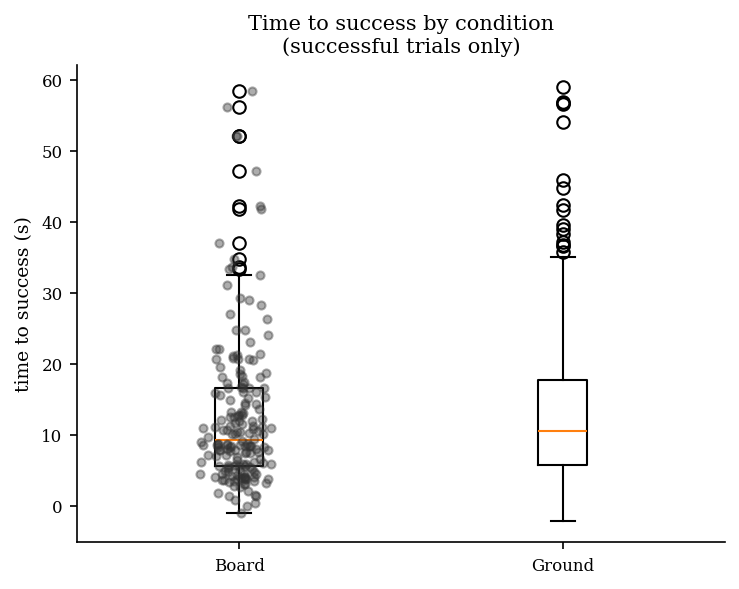

<Figure size 960x720 with 0 Axes>

In [18]:
COND_ORDER = ["board", "ground"]

print(succ.groupby("condition")["time_to_success"].agg(
n="size", median="median", mean="mean",
q25=lambda x: x.quantile(.25), q75=lambda x: x.quantile(.75)
).round(2))

groups = [succ.loc[succ.condition == c, "time_to_success"].values for c in COND_ORDER]

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(groups, tick_labels=[c.capitalize() for c in COND_ORDER])
rng = np.random.default_rng(0)
for i, g in enumerate(groups, start=1):
    ax.scatter(rng.normal(i, 0.05, size=len(g)), g, alpha=0.4, color="#333", s=15, zorder=3)
    ax.set_ylabel("time to success (s)")
    ax.set_title("Time to success by condition\n(successful trials only)")
    plt.tight_layout(); plt.show()

Median time to success was 9.31s on the board and 10.62s on the ground. Trials on the ground took a bit longer on average (means: 12.78s vs 14.39s too), but this is a small gap relative to the spread (IQR of roughly 5.7-17s in both conditions)

In [19]:
u, p = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
print(f"Trial-level Mann-Whitney U test: U = {u:.1f}, p = {p:.4f}")

Trial-level Mann-Whitney U test: U = 15587.0, p = 0.2918


Treating all 365 successful trials as independent observations, there is no significant difference between conditions. Given the ceiling effect and small sample, this alone is not conclusive either way but it is consistent with there not being a strong effect.

10 pairs have (successful-trial) data in both conditions:
condition  board  ground
pair_id                 
103_203    10.47   10.05
108_208     6.53   10.16
109_209     8.78    8.40
115_215     8.67    9.24
116_216    11.26   11.45
118_218    14.29   15.38
123_223    11.35   11.44
158_258    11.57   10.65
180_280     5.64    9.87
188_288    10.11    7.65

Wilcoxon signed-rank test (paired, per-pair median): W = 21.0, p = 0.5566


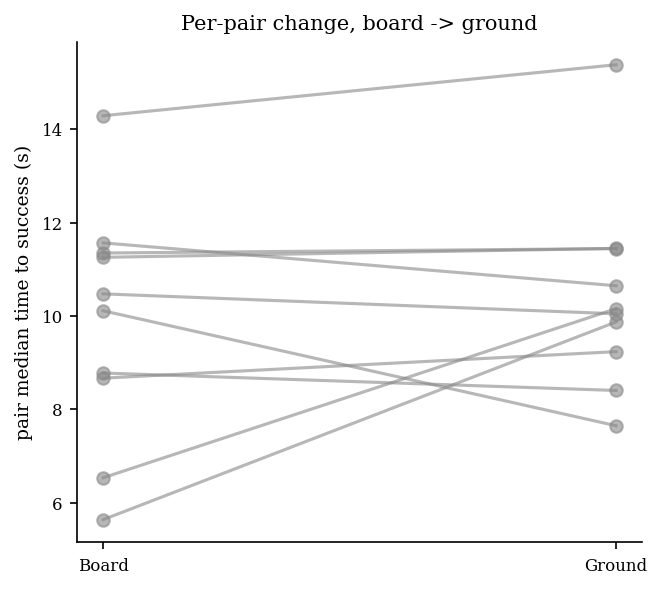

In [21]:
if within_pair:
    pair_cond = succ.groupby(["pair_id", "condition"])["time_to_success"].median().unstack()
    pair_cond = pair_cond.dropna()  # keep only pairs with a successful trial in both conditions
    print(f"{len(pair_cond)} pairs have (successful-trial) data in both conditions:")
    print(pair_cond.round(2))

    if len(pair_cond) >= 1:
        w_stat, p_w = stats.wilcoxon(pair_cond["board"], pair_cond["ground"])
        print(f"\nWilcoxon signed-rank test (paired, per-pair median): W = {w_stat:.1f}, p = {p_w:.4f}")

        fig, ax = plt.subplots(figsize=(4.5, 4))
        for _, row in pair_cond.iterrows():
            ax.plot([0, 1], [row["board"], row["ground"]], color="#888", alpha=0.6, marker="o")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Board", "Ground"])
        ax.set_ylabel("pair median time to success (s)")
        ax.set_title("Per-pair change, board -> ground")
        plt.tight_layout(); plt.show()
    else:
        print("No pairs have successful trials in both conditions -- can't run a paired test.")

else:
    pair_time = succ.groupby(["pair_id", "condition"])["time_to_success"].median().reset_index()
    groups2 = [pair_time.loc[pair_time.condition == c, "time_to_success"].values for c in COND_ORDER]
    u2, p2 = stats.mannwhitneyu(groups2[0], groups2[1], alternative="two-sided")
    print(f"Pair-level Mann-Whitney U test: U = {u2:.1f}, p = {p2:.4f}")

Six pairs were slower on the ground. Four pairs were slower on the board. Not a clean split but it is leaning toward the ground being slightly harder more often than not.

The Wilcoxon signed rank test looks at each pair's own board vs ground difference and asks whether the direction of change (positive vs negative) is consistent enough across pairs to be unlikely by chance.

The result (W=21.0, p=.557) is not significant. This is likely due to the high amount of noise introduced by only having 10 pairs. 

Possible reasons for this finding:
- The wobble board could increase arousal/alertness, thereby speeding up a concurrent task rather than only draining shared resources.
- The wobble board could lead to increased motivation/urgency to resolve the game faster so that they can return to stability.

However, the test was non-significant, meaning the trend we observe could point either way by pure chance. Therefore, there is no evidence that condition affects time to success, in either direction.

## Taboo word slips by condition

In [26]:
import re
 
trials_meta_dir = find_dir_with("trials_metadata.csv")
trials_meta = pd.read_csv(os.path.join(trials_meta_dir, "trials_metadata.csv"))
 
def morphological_variants(word):
    w = word.lower()
    v = {w, w + "s", w + "es"}
    if w.endswith("y") and len(w) > 1 and w[-2] not in "aeiou":
        v.add(w[:-1] + "ies")
    return v
 
def word_pattern(word):
    variants = sorted(morphological_variants(word), key=len, reverse=True)
    return re.compile(r"\b(?:" + "|".join(re.escape(v) for v in variants) + r")\b")
 
TABOO_COLS = [c for c in trials_meta.columns if c.startswith("taboo_")]
 
taboo_rows = []
for _, trial in trials_meta.iterrows():
    trial_id = trial.trial_id
    taboo_words = [trial[c] for c in TABOO_COLS if pd.notna(trial[c])]
    cg_text = " ".join(
        combined.loc[(combined.trial_id == trial_id) & (combined.role == "clue_giver"), "text"].astype(str)
    ).lower()
 
    violated = [w for w in taboo_words if word_pattern(w).search(cg_text)]
    taboo_rows.append(dict(
        trial_id=trial_id, pair_id=trial.pair_id, condition=trial.condition,
        n_taboo_violations=len(violated), any_violation=len(violated) > 0,
        violated_words=", ".join(violated),
    ))
 
taboo_df = pd.DataFrame(taboo_rows)
print(f"{taboo_df.any_violation.sum()}/{len(taboo_df)} trials have at least one taboo-word slip")
print(taboo_df[taboo_df.any_violation][["trial_id", "condition", "violated_words"]].to_string(index=False))


59/400 trials have at least one taboo-word slip
                                    trial_id condition violated_words
  103_203_19_1_20250113_152712_traffic_board     board           road
  103_203_40_1_20250113_153555_beauty_ground    ground          beast
   103_203_45_1_20250113_153745_walnut_board     board            eat
   103_203_48_1_20250113_153828_hunger_board     board  feeling, need
   103_203_50_1_20250113_153852_butter_board     board         yellow
  103_203_51_1_20250113_153926_cologne_board     board          smell
    103_203_53_1_20250113_154055_river_board     board            big
  108_208_14_1_20250114_162535_zipper_ground    ground          metal
   108_208_15_1_20250114_162542_gravy_ground    ground          brown
  108_208_18_1_20250114_162618_coffee_ground    ground          drink
  108_208_36_1_20250114_163248_balloon_board     board          round
108_208_40_1_20250114_163328_christmas_board     board       december
   108_208_43_1_20250114_163408_hunger_boa

### By condition
Rate is the proportion of trials with at least one slip. mean_n is the average number of distinct taboo words slipped per trial.

             n  violations   rate  mean_n
condition                                
board      200          31  0.155   0.175
ground     200          28  0.140   0.155


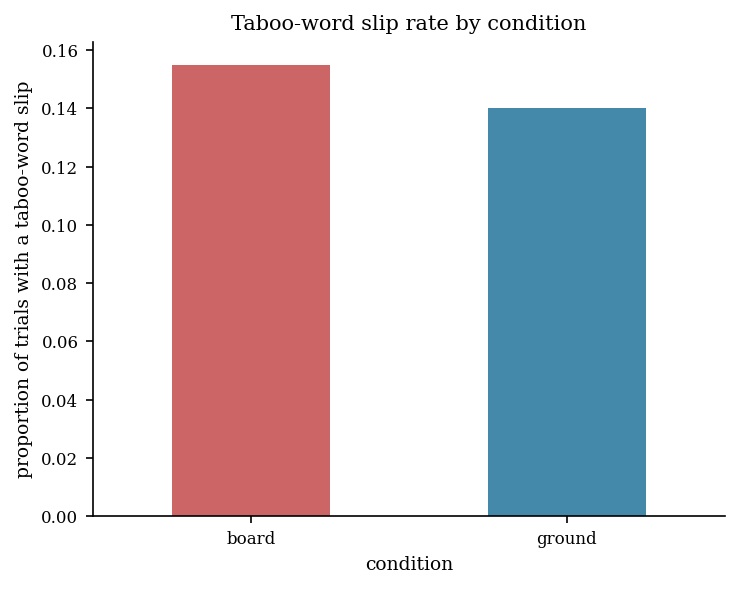

In [27]:
summary = taboo_df.groupby("condition").agg(
    n=("trial_id", "size"), violations=("any_violation", "sum"),
    rate=("any_violation", "mean"), mean_n=("n_taboo_violations", "mean"),
)
print(summary.round(3))
 
fig, ax = plt.subplots(figsize=(5, 4))
summary.loc[["board", "ground"], "rate"].plot.bar(ax=ax, color=["#c66", "#48a"])
ax.set_ylabel("proportion of trials with a taboo-word slip")
ax.set_title("Taboo-word slip rate by condition")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


Slightly higher slip rate for those on the board, but no significant difference.

### Trial level test:

In [ ]:
ct = pd.crosstab(taboo_df.condition, taboo_df.any_violation)
print(ct)
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"\nchi2 = {chi2:.3f}, df = {dof}, p = {p:.4f}")

any_violation  False  True 
condition                  
board            169     31
ground           172     28

chi2 = 0.080, df = 1, p = 0.7779


### Pair level test:

In [30]:
pair_cond = taboo_df.groupby(["pair_id", "condition"])["any_violation"].mean().unstack().dropna()
print(pair_cond.round(3))
 
if len(pair_cond) >= 1:
    w_stat, p_w = stats.wilcoxon(pair_cond["board"], pair_cond["ground"])
    print(f"\nWilcoxon signed-rank test (paired, per-pair slip rate): W = {w_stat:.1f}, p = {p_w:.4f}")
    print("(with slips this infrequent, many pairs will have zero in both conditions -- "
          "Wilcoxon drops those ties automatically, so check how many pairs actually "
          "contributed a non-zero difference before trusting this p-value)")
 


condition  board  ground
pair_id                 
103_203     0.30    0.05
108_208     0.20    0.15
109_209     0.20    0.40
115_215     0.05    0.05
116_216     0.00    0.10
118_218     0.10    0.10
123_223     0.00    0.05
158_258     0.15    0.10
180_280     0.35    0.15
188_288     0.20    0.25

Wilcoxon signed-rank test (paired, per-pair slip rate): W = 16.5, p = 0.8334
(with slips this infrequent, many pairs will have zero in both conditions -- Wilcoxon drops those ties automatically, so check how many pairs actually contributed a non-zero difference before trusting this p-value)


# Figures (more)

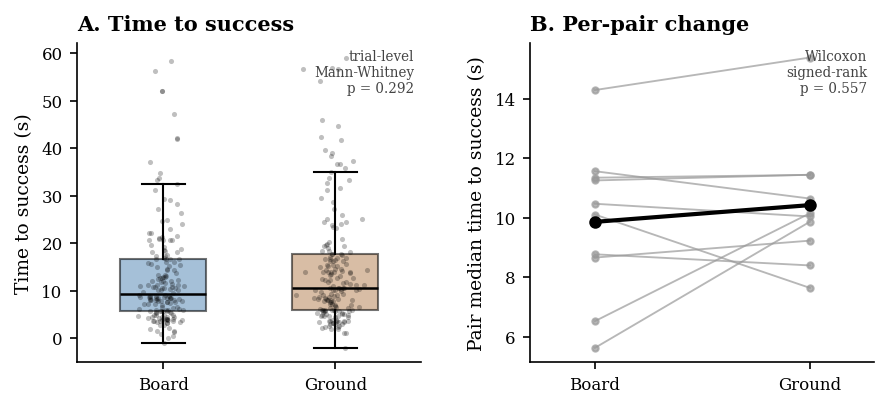

Saved fig_condition_time_to_success.pdf / .png


In [ ]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

COND_ORDER = ["board", "ground"]
COLORS = {"board": "#5B8DB8", "ground": "#B8875B"}

fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.8))

# Panel A: distribution (boxplot + jittered points)
ax = axes[0]
data = [succ.loc[succ.condition == c, "time_to_success"].values for c in COND_ORDER]
bp = ax.boxplot(data, tick_labels=[c.capitalize() for c in COND_ORDER], patch_artist=True,
                 widths=0.5, showfliers=False, medianprops=dict(color="black", linewidth=1.2))
for patch, c in zip(bp["boxes"], COND_ORDER):
    patch.set_facecolor(COLORS[c]); patch.set_alpha(0.55); patch.set_edgecolor("black")
rng = np.random.default_rng(0)
for i, c in enumerate(COND_ORDER, start=1):
    yvals = succ.loc[succ.condition == c, "time_to_success"].values
    ax.scatter(rng.normal(i, 0.06, size=len(yvals)), yvals, s=6, color="black", alpha=0.25, zorder=3, linewidths=0)
ax.set_ylabel("Time to success (s)")
ax.set_title("A. Time to success", loc="left", fontweight="bold")

u, p = stats.mannwhitneyu(data[0], data[1], alternative="two-sided")
ax.text(0.98, 0.98, f"trial-level\nMann-Whitney\np = {p:.3f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=6.5, color="#444")

# Panel B: paired per-pair change (spaghetti plot)
ax = axes[1]
pair_cond = succ.groupby(["pair_id", "condition"])["time_to_success"].median().unstack().dropna()
for _, row in pair_cond.iterrows():
    ax.plot([0, 1], [row["board"], row["ground"]], color="#999", alpha=0.7, marker="o",
             markersize=3, linewidth=0.9, zorder=2)
means = pair_cond.mean()
ax.plot([0, 1], [means["board"], means["ground"]], color="black", marker="o", markersize=5,
         linewidth=2, zorder=3, label="mean")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Board", "Ground"])
ax.set_xlim(-0.3, 1.3)
ax.set_ylabel("Pair median time to success (s)")
ax.set_title("B. Per-pair change", loc="left", fontweight="bold")

w_stat, p_w = stats.wilcoxon(pair_cond["board"], pair_cond["ground"])
ax.text(0.98, 0.98, f"Wilcoxon\nsigned-rank\np = {p_w:.3f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=6.5, color="#444")

plt.tight_layout(w_pad=2.5)
plt.savefig("fig_condition_time_to_success.pdf")
plt.savefig("fig_condition_time_to_success.png")
plt.show()

print("Saved fig_condition_time_to_success.pdf / .png")